# Let's look at Ridge regression using a **real-world dataset**: `load_diabetes`, which is built into scikit-learn (no download required).

It consists of 442 patients and 10 input variables; the target output is a measure of **disease progression one year later**.

The interesting part for today: six of these variables (`s1` through `s6`) are blood measurements, and several of them tell practically the same story. In other words, we are dealing with **genuine collinearity**, not a synthetic example.

| Step | What we'll cover |
|---|---|
| 1 | The dataset and collinearity |
| 2 | `LinearRegression`: coefficients that offset each other |
| 3 | `Ridge`: the same approach with a penalty |
| 4 | The role of `alpha` |
| 5 | Ridge vs. overfitting |
| 6 | Evaluation without the penalty |
| 7 | Why scaling is necessary |
| 8 | `RidgeCV`: letting scikit-learn find the optimal `alpha` |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import root_mean_squared_error


THETA, FEAT, YHAT, YREAL = "#F05133", "#3499CF", "#4ADE80", "#E879F9"
ERR, AMBER, ALPHA, TRAIN, VAL, PTS = "#F87171", "#FBBF24", "#22D3EE", "#F7931E", "#3499CF", "#CBD5E1"

plt.rcParams.update({
    "figure.facecolor": "#0A0E1A", "axes.facecolor": "#131826", "savefig.facecolor": "#0A0E1A",
    "axes.edgecolor": "#2A3349", "axes.labelcolor": "#94A3B8", "text.color": "#E8ECEF",
    "xtick.color": "#94A3B8", "ytick.color": "#94A3B8", "grid.color": "#1E2740",
    "axes.grid": True, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titleweight": "bold", "axes.titlesize": 13, "font.size": 11, "figure.dpi": 110,
    "legend.frameon": False,
})

## 1 The dataset and collinearity

We load it **unscaled** (`scaled=False`) to see the actual units for each variable. Keep this in mind, as it will be important in step 7.

- `age`, `sex`, `bmi` (body mass index), `bp` (blood pressure)
- `s1` total cholesterol · `s2` LDL · `s3` HDL · `s4` total cholesterol / HDL · `s5` log of triglycerides · `s6` glucose

In [2]:
data = load_diabetes(as_frame=True, scaled=False)
X, y = data.data, data.target

print(X.shape)
X.describe().loc[["mean", "std", "min", "max"]].round(2)

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00


Look at the ranges: `s1` is around 190, while `s5` is around 4.6. Very different units.

Now, consider collinearity. LDL (`s2`) is a component of total cholesterol (`s1`), so the two variables move together. It is the same scenario as `age_days` and `age_years` from the slides, but with real data.

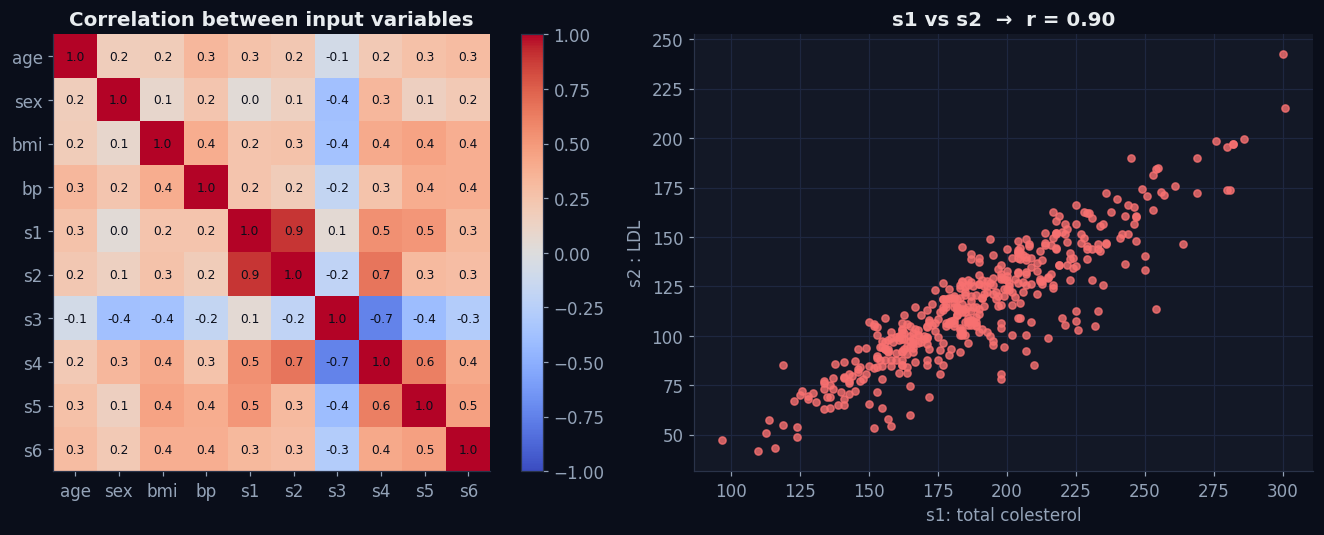

In [3]:
corr = X.corr()
r = corr.loc["s1", "s2"]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

im = ax[0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[0].set_xticks(range(10), X.columns); ax[0].set_yticks(range(10), X.columns)
ax[0].grid(False); ax[0].set_title("Correlation between input variables")
for i in range(10):
    for j in range(10):
        ax[0].text(j, i, f"{corr.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8, color="#0A0E1A")
fig.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].scatter(X["s1"], X["s2"], s=22, color=ERR, alpha=0.8)
ax[1].set_xlabel("s1: total colesterol"); ax[1].set_ylabel("s2 : LDL")
ax[1].set_title(f"s1 vs s2  →  r = {r:.2f}")
plt.tight_layout(); plt.show()

## 2 `LinearRegression`: coefficients that offset each other

We split the data into three parts: **train** for training, **validation** for comparing `alpha` values, and **test**, which remains untouched until the end.

The model is placed inside a `Pipeline` with `StandardScaler` so that all coefficients are on the same scale, allowing us to compare them with one another.

In [4]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42)
print(len(X_train), "train :", len(X_val), "validation :", len(X_test), "test")

lin_reg = make_pipeline(StandardScaler(), LinearRegression())
lin_reg.fit(X_train, y_train)

coef_lr = pd.Series(lin_reg[-1].coef_, index=X.columns)
coef_lr.round(1)

264 train : 89 validation : 89 test


age     1.1
sex   -11.4
bmi    25.1
bp     15.2
s1    -51.1
s2     27.5
s3     10.8
s4     15.0
s5     37.3
s6      3.8
dtype: float64

Look at `s1` and `s2`: `s1` is the largest coefficient of all (in absolute value), and `s2` has the **opposite sign**. The two variables convey almost the same information, so the model assigns a large weight to one and cancels it out with the other.

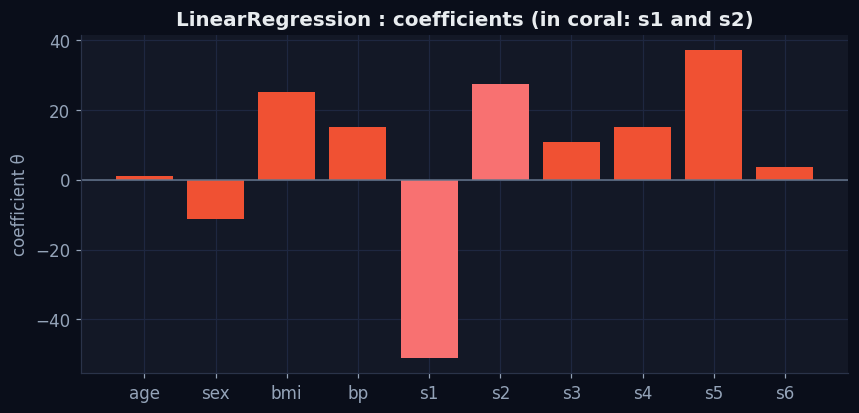

In [5]:
def plot_coefs(ax, coefs, title, color=THETA):
    ax.bar(coefs.index, coefs.values, color=[ERR if c in ("s1", "s2") else color for c in coefs.index])
    ax.axhline(0, color="#64748B", lw=1)
    ax.set_title(title); ax.set_ylabel("coefficient θ")

fig, ax = plt.subplots(figsize=(9, 4))
plot_coefs(ax, coef_lr, "LinearRegression : coefficients (in coral: s1 and s2)")
plt.show()

## 3 `Ridge`: the same recipe with a penalty

The only change in the code is the estimator. The cost function shifts from

$$\text{Error} = \sum (y - \hat{y})^2 \qquad \text{to} \qquad \text{Error} = \sum (y - \hat{y})^2 + \alpha \sum \theta^2$$

Note a specific detail from the book: the intercept term $\theta_0$ **is not penalized**; the summation starts at $\theta_1$. Scikit-learn handles this automatically.

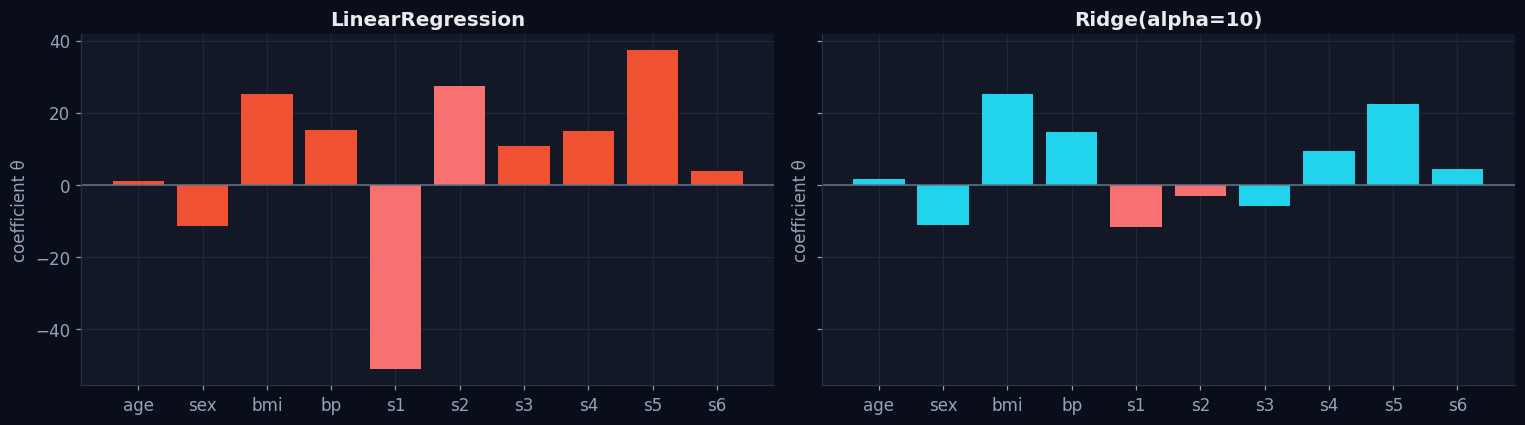

,LinearRegression,Ridge(alpha=10)
s1,-51.1,-11.7
s2,27.5,-2.9


In [6]:
ridge_reg = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge_reg.fit(X_train, y_train)
coef_ridge = pd.Series(ridge_reg[-1].coef_, index=X.columns)

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_coefs(ax[0], coef_lr, "LinearRegression")
plot_coefs(ax[1], coef_ridge, "Ridge(alpha=10)", color=ALPHA)
plt.tight_layout(); plt.show()

pd.DataFrame({"LinearRegression": coef_lr, "Ridge(alpha=10)": coef_ridge}).loc[["s1", "s2"]].round(1)

The `s1` / `s2` pair is no longer canceling each other out: Ridge prefers to distribute the weight rather than incur the cost of two huge coefficients.

We can also verify the point made in the slides—that linear regression coefficients are **highly sensitive to small changes in the data** by training the model eight times, each time removing a different 10% of the rows, and observing what happens to the `s1` coefficient.

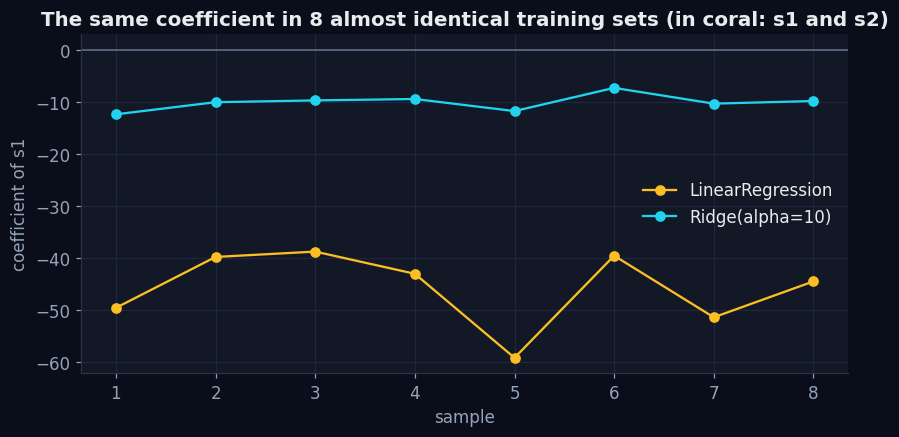

LinearRegression: from -59.2 to -38.8 (range 20.4)
Ridge(alpha=10): from -12.4 to -7.3 (range 5.1)


In [7]:
def coef_s1(model, seed):
    idx = np.random.default_rng(seed).choice(len(X_train), size=int(len(X_train) * 0.9), replace=False)
    model.fit(X_train.iloc[idx], y_train.iloc[idx])
    return model[-1].coef_[list(X.columns).index("s1")]

s1_lr = [coef_s1(make_pipeline(StandardScaler(), LinearRegression()), s) for s in range(8)]
s1_ridge = [coef_s1(make_pipeline(StandardScaler(), Ridge(alpha=10)), s) for s in range(8)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 9), s1_lr, "o-", color=AMBER, label="LinearRegression")
ax.plot(range(1, 9), s1_ridge, "o-", color=ALPHA, label="Ridge(alpha=10)")
ax.axhline(0, color="#64748B", lw=1)
ax.set_xlabel("sample"); ax.set_ylabel("coefficient of s1"); ax.legend()
ax.set_title("The same coefficient in 8 almost identical training sets (in coral: s1 and s2)")
plt.show()

print(f"LinearRegression: from {min(s1_lr):.1f} to {max(s1_lr):.1f} (range {max(s1_lr) - min(s1_lr):.1f})")
print(f"Ridge(alpha=10): from {min(s1_ridge):.1f} to {max(s1_ridge):.1f} (range {max(s1_ridge) - min(s1_ridge):.1f})")

## 4 Why scaling is necessary

Ridge penalizes the **magnitude** of the coefficient, and that magnitude depends on the units. `s5` has very small values ​​(around 4.6), so it requires a large coefficient to have an impact on the prediction. Without scaling, Ridge will penalize it more heavily than the others simply because of how it is measured.

To make a fair comparison, we look at the **actual effect** of each variable: coefficient × standard deviation.

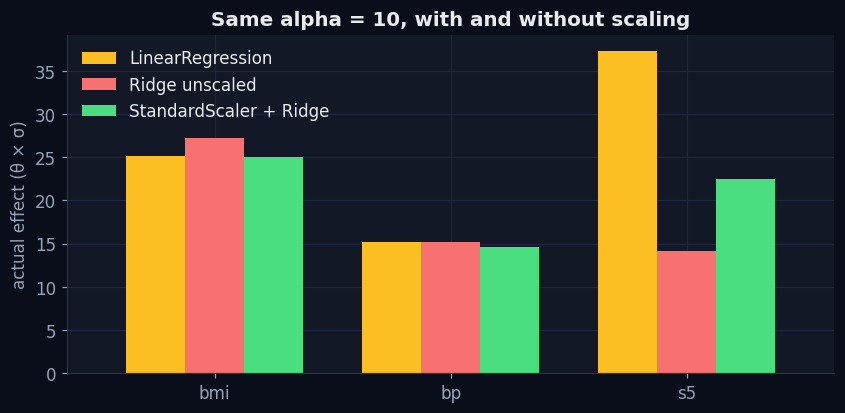

Unscaled s5 coefficient → LinearRegression: 74.3 · Ridge: 28.3


,LinearRegression,Ridge unscaled,StandardScaler + Ridge
bmi,25.1,27.2,25.1
bp,15.2,15.2,14.6
s5,37.3,14.2,22.5


In [8]:
sd = X_train.std()

lr_raw = LinearRegression().fit(X_train, y_train)
ridge_raw = Ridge(alpha=10).fit(X_train, y_train)                                   # unscaled
ridge_scaled = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(X_train, y_train)  # scaled

effect = pd.DataFrame({
    "LinearRegression": lr_raw.coef_ * sd,
    "Ridge unscaled": ridge_raw.coef_ * sd,
    "StandardScaler + Ridge": ridge_scaled[-1].coef_,
}, index=X.columns)

ax = effect.loc[["bmi", "bp", "s5"]].plot.bar(figsize=(9, 4), color=[AMBER, ERR, YHAT], rot=0, width=0.75)
ax.set_ylabel("actual effect (θ × σ)"); ax.set_title("Same alpha = 10, with and without scaling")
plt.show()

print("Unscaled s5 coefficient → LinearRegression:", lr_raw.coef_[8].round(1), "· Ridge:", ridge_raw.coef_[8].round(1))
effect.loc[["bmi", "bp", "s5"]].round(1)

Without scaling, `s5` is the variable that loses the most, whereas `bmi` and `bp` are barely affected by the penalty. With `StandardScaler`, they all play by the same rules.

That is why `StandardScaler` goes **inside the Pipeline**, before Ridge. And the same applies to Lasso, ElasticNet, penalized logistic regression, and SVM.

## 8 `RidgeCV`: letting scikit-learn find the `alpha`

We have previously worked with `alpha` manually using a validation set. `RidgeCV` performs the same task using cross-validation; since it is optimized for Ridge, it is much faster than `GridSearchCV`.

Because it uses cross-validation, we pass the training and validation data combined. We use the test set only once—here at the end.

In [9]:
ridge_cv = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-2, 4, 50)),
)
ridge_cv.fit(X_trainval, y_trainval)

sin_reg = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression(),
).fit(X_trainval, y_trainval)

print(f"alpha chosen by RidgeCV: {ridge_cv[-1].alpha_:.2f}")
print(f"RMSE test : unregularized: {root_mean_squared_error(y_test, sin_reg.predict(X_test)):.2f}")
print(f"RMSE test : RidgeCV: {root_mean_squared_error(y_test, ridge_cv.predict(X_test)):.2f}")

alpha chosen by RidgeCV: 109.85
RMSE test : unregularized: 55.64
RMSE test : RidgeCV: 53.49


---

# Task · Ridge Regression on California Housing Prices

Now it's your turn. We will use `fetch_california_housing`, another dataset included with scikit-learn (it downloads automatically the first time; it is about 400 KB in size).

It consists of **20,640 California districts** and 8 input variables; the target output is the **median house value in hundreds of thousands of dollars** (a value of 2.5 means $250,000).

| Variable | Description |
|---|---|
| `MedInc` | median income in the district |
| `HouseAge` | median age of houses |
| `AveRooms` | average rooms per dwelling |
| `AveBedrms` | average bedrooms per dwelling |
| `Population` | district population |
| `AveOccup` | average people per dwelling |
| `Latitude`, `Longitude` | location |

**Objective:** Build a polynomial model that does **not** overfit—using a `Pipeline` with `StandardScaler` and `RidgeCV`—and find the best `alpha`.

Follow the steps in order. Each step has hidden hints; open them only if you get stuck. **The solution is at the end of the notebook—no cheating.**

### Step 1: Load and explore

1. Load the dataset into `X` (DataFrame) and `y`.
2. Examine the `mean`, `std`, `min`, and `max` for each column. Which variables have vastly different scales? Do you notice any outliers?
3. Calculate the correlation matrix and identify **two pairs of variables exhibiting collinearity** (|r| > 0.8).

<details><summary>Hint 1</summary>

`fetch_california_housing(return_X_y=True, as_frame=True)` returns `X` and `y` directly.
</details>

<details><summary>Hint 2</summary>

This is the same process we used for the diabetes dataset: `X.describe().loc[["mean", "std", "min", "max"]]` and `X.corr()`.
Pay attention to the `max` values ​​for `AveOccup` and `AveRooms`.
</details>

<details><summary>Hint 3</summary>

One pair relates to the size of the housing unit, and the other relates to the location on the map.
</details>

In [ ]:
from sklearn.datasets import fetch_california_housing

# Step 1: Your code here

### Step 2: Split into train and test sets

Set aside 20% for the test set using `random_state=42`. Name them `Xc_train`, `Xc_test`, `yc_train`, and `yc_test` to avoid overwriting the diabetes variables.

<details><summary>Hint</summary>

`train_test_split(X, y, test_size=0.2, random_state=42)`. You don't need a separate validation set this time: `RidgeCV` performs cross-validation internally.
</details>

In [ ]:
# Step 2: Your code here

### Step 3 Baseline model: linear regression

Build a pipeline using `StandardScaler` + `LinearRegression`, train it, and calculate the **test RMSE**. This figure represents the baseline we need to improve upon.

Also, examine the coefficients: what happens to the signs of the collinear variables identified in Step 1?

<details><summary>Hint 1</summary>

`make_pipeline(StandardScaler(), LinearRegression())`, just like in section 2 of the lab.
</details>

<details><summary>Hint 2</summary>

`root_mean_squared_error(yc_test, modelo.predict(Xc_test))`. The coefficients are found in `modelo[-1].coef_`.
</details>

In [10]:
# Step 3: Your code here

### Step 4 Adding complexity: 3rd-degree polynomial

The relationship with the price is not a straight line, so let's add complexity: `PolynomialFeatures(degree=3)` before scaling and `LinearRegression` at the end.

1. Calculate the RMSE for the **train** and **test** sets. What happened? What is this phenomenon called?
2. How many coefficients does the model have now? Which one is the largest in absolute value?

<details><summary>Hint 1</summary>

The order of the pipeline matters: `PolynomialFeatures(degree=3, include_bias=False)` → `StandardScaler()` → `LinearRegression()`.
First, the new variables are created, and **then** they are scaled so that they all share the same scale.
</details>

<details><summary>Hint 2</summary>

`np.abs(modelo[-1].coef_).max()` and `modelo[-1].coef_.size`. Compare the training RMSE with the test RMSE: if the training error is low and the test error skyrockets, it is overfitting.
</details>

In [ ]:
# Step 4: Your code here

### Step 5: Ridge with `RidgeCV` – finding the best `alpha`

Use **the same pipeline** from Step 4, but replace `LinearRegression` with `RidgeCV` and a list of alpha values ​​to test.

1. Which `alpha` was selected? What is the test RMSE? Does it outperform the baseline model from Step 3?
2. **Check if the selected `alpha` is at the edge of the list.** If so, expand the range and retrain.
3. What is the magnitude of the largest coefficient now?

<details><summary>Hint 1</summary>

`RidgeCV(alphas=np.logspace(-3, 3, 50))` tests 50 values ​​between 0.001 and 1000. The selected value is stored in `modelo[-1].alpha_`.
</details>

<details><summary>Hint 2</summary>

If `alpha_` is exactly the highest (or lowest) value in the list, it means `RidgeCV` wanted to go further but was constrained by the range provided. Try using `np.logspace(-3, 5, 50)`.
</details>

<details><summary>Hint 3</summary>

Compare the `max(|θ|)` with the one from Step 4: Ridge should have reduced it from the hundreds to less than 1.
</details>

In [ ]:
# Step 5: Your code here

### Step 6: What if we don't scale?

Repeat Step 5 **without** `StandardScaler` and compare the test RMSE. Explain in your own words why this happens.

<details><summary>Hint</summary>

Recall Section 4 of the lab: Ridge penalizes the **magnitude** of each coefficient, and that magnitude depends on the units. With a third-degree polynomial, `Population`³ reaches huge values, while `AveBedrms`³ remains very small.
</details>

In [ ]:
# Step 6: Your code here

### Step 7 Conclusion

Create a table (or bar chart) showing the test RMSE for the four models and answer the following in 2 or 3 sentences:

- Which is the best model, and why?
- What did each component of the pipeline—`PolynomialFeatures`, `StandardScaler`, and `RidgeCV`—contribute?

In [11]:
# Step 7: Your code here

---
---
# Solution

**Do not scroll down if you haven't tried it yet.**

&nbsp;

&nbsp;

&nbsp;

### Step 1 Solution

`MedInc` is around 4 and `Population` around 1,400: very different scales. `AveOccup` reaches over 1,200 people per household and `AveRooms` up to 140 rooms: there are extreme values.

Collinearity: `AveRooms` and `AveBedrms` (r ≈ 0.85; more rooms implies more bedrooms) and `Latitude` and `Longitude` (r ≈ -0.92; due to California's diagonal shape).

In [13]:
from sklearn.datasets import fetch_california_housing

Xc, yc = fetch_california_housing(return_X_y=True, as_frame=True)
print(Xc.shape)

display(Xc.describe().loc[["mean", "std", "min", "max"]].round(2))

corr_c = Xc.corr()

pairs = corr_c.where(np.triu(np.ones(corr_c.shape, dtype=bool), k=1)).stack()
pairs[pairs.abs() > 0.8].round(2).sort_values(ascending=False)

(20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


AveRooms  AveBedrms    0.85
Latitude  Longitude   -0.92
dtype: float64

### Step 2 Solution

In [14]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)
print(len(Xc_train), "train_size :", len(Xc_test), "test_size")

16512 train_size : 4128 test_size


### Step 3 Solution

Test RMSE ≈ **0.746** (an average error of around USD 74,600). Regarding the coefficients, `AveRooms` and `AveBedrms` appear with **opposite signs**, just like `s1` and `s2` in the diabetes dataset.

In [15]:
base = make_pipeline(StandardScaler(), LinearRegression()).fit(Xc_train, yc_train)
rmse_base = root_mean_squared_error(yc_test, base.predict(Xc_test))

print(f"RMSE test : LinearRegression: {rmse_base:.3f}")

pd.Series(base[-1].coef_, index=Xc.columns).round(3).sort_values(ascending=False)

RMSE test : LinearRegression: 0.746


MedInc        0.854
AveBedrms     0.339
HouseAge      0.123
Population   -0.002
AveOccup     -0.041
AveRooms     -0.294
Longitude    -0.870
Latitude     -0.897
dtype: float64

### Solution Step 4

Train ≈ **0.585**, test ≈ **4.98**: the model learned the noise in the training set, and on the test set, its error is nearly seven times higher than that of the baseline model. This is **overfitting**.

With a degree of 3, we go from 8 to **164 coefficients**, and the largest one exceeds **1,000**. These are massive weights: a small change in a variable causes a huge shift in the prediction.

In [16]:
poly_lr = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    LinearRegression(),
).fit(Xc_train, yc_train)

rmse_poly = root_mean_squared_error(yc_test, poly_lr.predict(Xc_test))

print(f"RMSE train: {root_mean_squared_error(yc_train, poly_lr.predict(Xc_train)):.3f}")
print(f"RMSE test: {rmse_poly:.3f}")
print(f"coefficients: {poly_lr[-1].coef_.size} max |θ| = {np.abs(poly_lr[-1].coef_).max():.1f}")

RMSE train: 0.585
RMSE test: 5.041
coefficients: 164 max |θ| = 3740.6


### Step 5 Solution

With `np.logspace(-3, 3, 50)`, `RidgeCV` selects `alpha = 1000`: **the edge of the list**. We wanted to apply more regularization, but the range didn't allow it.

By expanding the range to `np.logspace(-3, 5, 50)`, it selects `alpha ≈ 3393`; the test RMSE drops to ≈ **0.728** (beating the baseline model), and the largest coefficient ends up at ≈ **0.14**.

The takeaway: **always check that the chosen `alpha` isn't at the extreme end of the range.**

In [20]:
def ridge_poly(alphas, scaler=True):
    steps = [PolynomialFeatures(degree=3, include_bias=False)]
    if scaler:
        steps.append(StandardScaler())
    steps.append(RidgeCV(alphas=alphas))
    return make_pipeline(*steps).fit(Xc_train, yc_train)


for alphas in (np.logspace(-3, 3, 50), np.logspace(-3, 5, 50)):
    model = ridge_poly(alphas)
    a = model[-1].alpha_
    border = " ← on border, expand" if np.isclose(a, alphas.max()) or np.isclose(a, alphas.min()) else "" 
    print(f"range {alphas.min():g} to {alphas.max():g} → alpha = {a:.1f}{border}")

best_ridge = model
rmse_ridge = root_mean_squared_error(yc_test, best_ridge.predict(Xc_test))
print(f"\nRMSE test RidgeCV: {rmse_ridge:.3f} (base {rmse_base:.3f})")
print(f"max |θ| = {np.abs(best_ridge[-1].coef_).max():.2f} (without Ridge: {np.abs(poly_lr[-1].coef_).max():.1f})")

range 0.001 to 1000 → alpha = 1000.0 ← on border, expand
range 0.001 to 100000 → alpha = 3393.2

RMSE test RidgeCV: 0.728 (base 0.746)
max |θ| = 0.14 (without Ridge: 3740.6)


### Step 6 Solution

Without scaling, the test RMSE skyrockets to ≈ **17**. The new polynomial features have vastly different scales (`Population`³ is huge, `AveBedrms`³ is tiny), so Ridge penalizes some more than others simply due to their units. With such unequal scales, no single `alpha` works for all of them simultaneously, and `RidgeCV` ends up choosing a value close to zero—meaning it applies virtually no regularization.

In [21]:
ridge_without_scalar = ridge_poly(np.logspace(-3, 5, 50), scaler=False)
unscaled_rmse = root_mean_squared_error(yc_test, ridge_without_scalar.predict(Xc_test))
print(f"alpha = {ridge_without_scalar[-1].alpha_:.3g} RMSE test unscalar: {unscaled_rmse:.3f}")

alpha = 1e+05 RMSE test unscalar: 476120.780


### Step 7 Solution

- **Best model:** `PolynomialFeatures(3)` + `StandardScaler` + `RidgeCV`. It captures curves that a straight line misses and, thanks to the penalty, avoids learning the noise.
- `PolynomialFeatures` provides the complexity, `StandardScaler` ensures the penalty is applied fairly across all variables, and `RidgeCV` determines the appropriate amount of penalty.

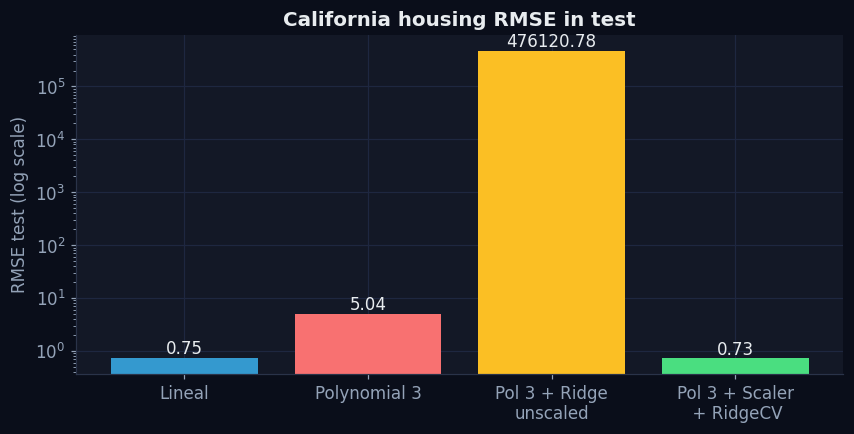

Lineal                             0.746
Polynomial 3                       5.041
Pol 3 + Ridge\nunscaled       476120.780
Pol 3 + Scaler\n + RidgeCV         0.728
dtype: float64

In [22]:
results = pd.Series({
    "Lineal": rmse_base,
    "Polynomial 3": rmse_poly,
    "Pol 3 + Ridge\nunscaled": unscaled_rmse,
    "Pol 3 + Scaler\n + RidgeCV": rmse_ridge,
})

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(results.index, results.values, color=[FEAT, ERR, AMBER, YHAT])
ax.bar_label(bars, fmt="%.2f", color="#E8ECEF")
ax.set_yscale("log"); ax.set_ylim(top=results.max() * 2); ax.set_ylabel("RMSE test (log scale)")
ax.set_title("California housing RMSE in test")
plt.show()

results.round(3)